# Homework ODE

The objective is to implement an embedded Runge--Kutta stepper with an error estimate and an adaptive step-size driver for initial value problems of ordinary differential equations.


# Task A: Embedded Runge--Kutta ODE integrator

In this part I implement:

- an embedded midpoint/Euler Runge--Kutta stepper `rkstep12`,
- an adaptive step-size driver,
- tests on simple ODE systems.

In [1]:
from pathlib import Path

Path("ode.hpp").write_text(r'''
#pragma once

#include <vector>
#include <functional>
#include <tuple>
#include <cmath>
#include <stdexcept>
#include <algorithm>

namespace pp {

using vec = std::vector<double>;
using ode_function = std::function<vec(double, const vec&)>;

inline void check_same_size(const vec& a, const vec& b) {
    if (a.size() != b.size()) {
        throw std::runtime_error("vector size mismatch");
    }
}

inline vec operator+(const vec& a, const vec& b) {
    check_same_size(a, b);
    vec c(a.size());
    for (std::size_t i = 0; i < a.size(); ++i) {
        c[i] = a[i] + b[i];
    }
    return c;
}

inline vec operator-(const vec& a, const vec& b) {
    check_same_size(a, b);
    vec c(a.size());
    for (std::size_t i = 0; i < a.size(); ++i) {
        c[i] = a[i] - b[i];
    }
    return c;
}

inline vec operator*(const vec& a, double c) {
    vec b(a.size());
    for (std::size_t i = 0; i < a.size(); ++i) {
        b[i] = a[i] * c;
    }
    return b;
}

inline vec operator*(double c, const vec& a) {
    return a * c;
}

inline vec operator/(const vec& a, double c) {
    vec b(a.size());
    for (std::size_t i = 0; i < a.size(); ++i) {
        b[i] = a[i] / c;
    }
    return b;
}

inline double norm(const vec& a) {
    double s = 0.0;
    for (double x : a) {
        s += x * x;
    }
    return std::sqrt(s);
}

/*
Task A1:
Embedded midpoint/Euler Runge--Kutta stepper.

Euler:
    k0 = f(x,y)
    y_euler = y + h*k0

Midpoint:
    k1 = f(x+h/2, y + h*k0/2)
    y_midpoint = y + h*k1

The error estimate is the difference between the midpoint and Euler slopes:
    dy = h*(k1-k0)
*/
inline std::tuple<vec, vec> rkstep12(
    ode_function f,
    double x,
    const vec& y,
    double h
) {
    vec k0 = f(x, y);
    vec k1 = f(x + h/2.0, y + k0*(h/2.0));

    vec yh = y + k1*h;
    vec dy = (k1 - k0)*h;

    return {yh, dy};
}

struct ode_solution {
    std::vector<double> x;
    std::vector<vec> y;
    int accepted_steps = 0;
    int rejected_steps = 0;
};

/*
Task A2:
Adaptive step-size driver.

The driver adjusts h so that the estimated local error is below the local tolerance

    tol = (acc + eps*||y||)*sqrt(h/(b-a)).

Accepted steps are stored in xlist and ylist.
*/
inline ode_solution driver(
    ode_function f,
    double a,
    double b,
    const vec& yinit,
    double h = 0.125,
    double acc = 0.01,
    double eps = 0.01
) {
    if (a == b) {
        return ode_solution{{a}, {yinit}, 0, 0};
    }

    const double interval = b - a;
    const double direction = (interval > 0.0) ? 1.0 : -1.0;

    if (h == 0.0) {
        throw std::runtime_error("initial step size h cannot be zero");
    }

    if (direction*h < 0.0) {
        h = -h;
    }

    double x = a;
    vec y = yinit;

    ode_solution sol;
    sol.x.push_back(x);
    sol.y.push_back(y);

    const int max_steps = 1000000;

    for (int step = 0; step < max_steps; ++step) {
        if (direction*(x - b) >= 0.0) {
            return sol;
        }

        if (direction*(x + h - b) > 0.0) {
            h = b - x;
        }

        if (std::abs(h) < 1e-14) {
            throw std::runtime_error("step size became too small");
        }

        vec yh, dy;
        std::tie(yh, dy) = rkstep12(f, x, y, h);

        double tol = (acc + eps*norm(yh))*std::sqrt(std::abs(h/interval));
        double err = norm(dy);

        if (err <= tol) {
            x += h;
            y = yh;

            sol.x.push_back(x);
            sol.y.push_back(y);
            sol.accepted_steps += 1;
        } else {
            sol.rejected_steps += 1;
        }

        double factor;
        if (err > 0.0) {
            factor = 0.95*std::pow(tol/err, 0.25);
            factor = std::min(factor, 2.0);
            factor = std::max(factor, 0.1);
        } else {
            factor = 2.0;
        }

        h *= factor;
    }

    throw std::runtime_error("driver exceeded max_steps");
}

} // namespace pp
''')

print("Wrote ode.hpp")

Wrote ode.hpp


In [2]:
Path("ode_A.cpp").write_text(r'''
#include "ode.hpp"

#include <iostream>
#include <fstream>
#include <iomanip>
#include <cmath>

int main() {
    std::cout << "Task A: embedded Runge--Kutta ODE integrator\n";
    std::cout << "------------------------------------------------\n";

    /*
    Test 1: harmonic oscillator

        u'' = -u

    rewritten as

        y0' = y1
        y1' = -y0

    with exact solution u(x)=cos(x) for y(0)=(1,0).
    */
    pp::ode_function oscillator = [](double x, const pp::vec& y) {
        (void)x;
        return pp::vec{y[1], -y[0]};
    };

    double a = 0.0;
    double b = 6.0*M_PI;
    pp::vec y0 = {1.0, 0.0};

    auto osc = pp::driver(
        oscillator,
        a,
        b,
        y0,
        0.25,
        1e-4,
        1e-4
    );

    std::ofstream osc_file("ode_A_oscillator.data");
    osc_file << "# x u_numeric v_numeric u_exact abs_error\n";

    double max_error = 0.0;

    for (std::size_t i = 0; i < osc.x.size(); ++i) {
        double x = osc.x[i];
        double u = osc.y[i][0];
        double v = osc.y[i][1];
        double exact = std::cos(x);
        double error = std::abs(u - exact);

        max_error = std::max(max_error, error);

        osc_file
            << std::setprecision(16)
            << x << " "
            << u << " "
            << v << " "
            << exact << " "
            << error << "\n";
    }

    std::cout << "\nHarmonic oscillator test\n";
    std::cout << "accepted steps = " << osc.accepted_steps << "\n";
    std::cout << "rejected steps = " << osc.rejected_steps << "\n";
    std::cout << "max |u-cos(x)| = " << max_error << "\n";
    std::cout << "Wrote ode_A_oscillator.data\n";

    /*
    Test 2: Lotka--Volterra predator-prey system

        x' = alpha*x - beta*x*y
        y' = delta*x*y - gamma*y
    */
    const double alpha = 1.5;
    const double beta  = 1.0;
    const double delta = 1.0;
    const double gamma = 3.0;

    pp::ode_function lotka = [=](double t, const pp::vec& y) {
        (void)t;
        double prey = y[0];
        double predator = y[1];

        return pp::vec{
            alpha*prey - beta*prey*predator,
            delta*prey*predator - gamma*predator
        };
    };

    auto lv = pp::driver(
        lotka,
        0.0,
        15.0,
        pp::vec{10.0, 5.0},
        0.05,
        1e-4,
        1e-4
    );

    std::ofstream lv_file("ode_A_lotka_volterra.data");
    lv_file << "# t prey predator\n";

    for (std::size_t i = 0; i < lv.x.size(); ++i) {
        lv_file
            << std::setprecision(16)
            << lv.x[i] << " "
            << lv.y[i][0] << " "
            << lv.y[i][1] << "\n";
    }

    std::cout << "\nLotka--Volterra test\n";
    std::cout << "accepted steps = " << lv.accepted_steps << "\n";
    std::cout << "rejected steps = " << lv.rejected_steps << "\n";
    std::cout << "Wrote ode_A_lotka_volterra.data\n";

    return 0;
}
''')

print("Wrote ode_A.cpp")

Wrote ode_A.cpp


In [3]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "ode_A.cpp",
    "-o",
    "ode_A"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./ode_A"], text=True, capture_output=True)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A: embedded Runge--Kutta ODE integrator
------------------------------------------------

Harmonic oscillator test
accepted steps = 10595
rejected steps = 8
max |u-cos(x)| = 9.13179e-06
Wrote ode_A_oscillator.data

Lotka--Volterra test
accepted steps = 30286
rejected steps = 8
Wrote ode_A_lotka_volterra.data




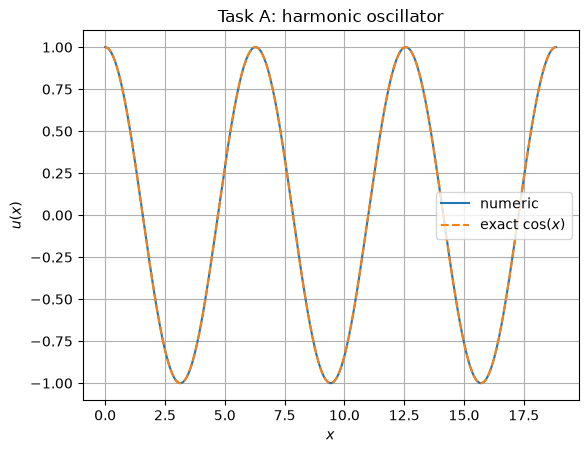

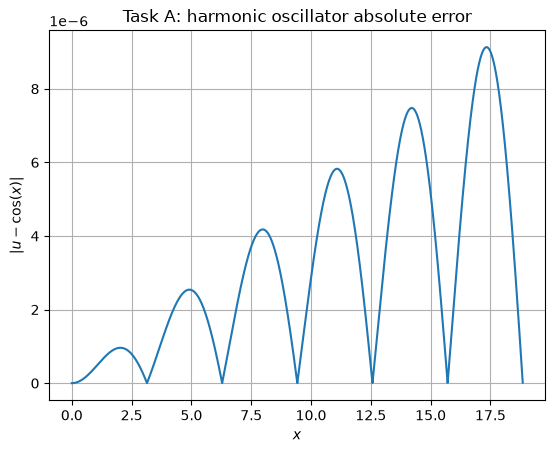

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ode_A_oscillator.data")
x = data[:, 0]
u = data[:, 1]
u_exact = data[:, 3]
err = data[:, 4]

plt.figure()
plt.plot(x, u, label="numeric")
plt.plot(x, u_exact, "--", label=r"exact $\cos(x)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$u(x)$")
plt.title("Task A: harmonic oscillator")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x, err)
plt.xlabel(r"$x$")
plt.ylabel(r"$|u-\cos(x)|$")
plt.title("Task A: harmonic oscillator absolute error")
plt.grid(True)
plt.show()

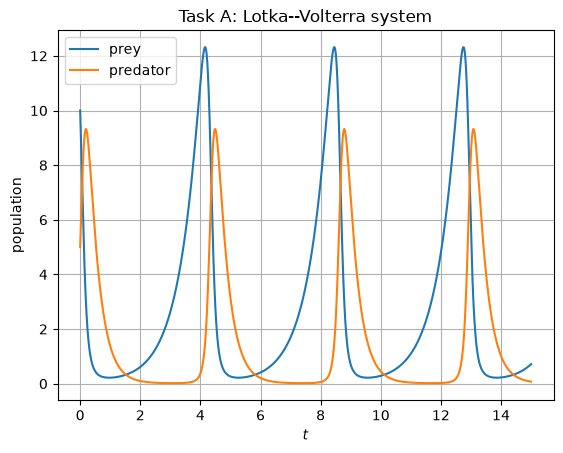

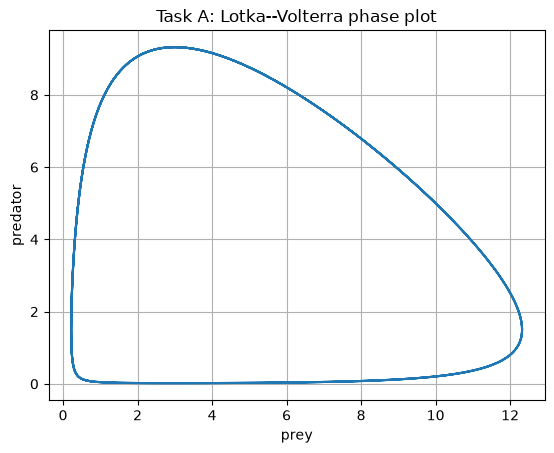

In [5]:
lv = np.loadtxt("ode_A_lotka_volterra.data")
t = lv[:, 0]
prey = lv[:, 1]
predator = lv[:, 2]

plt.figure()
plt.plot(t, prey, label="prey")
plt.plot(t, predator, label="predator")
plt.xlabel(r"$t$")
plt.ylabel("population")
plt.title("Task A: Lotka--Volterra system")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(prey, predator)
plt.xlabel("prey")
plt.ylabel("predator")
plt.title("Task A: Lotka--Volterra phase plot")
plt.grid(True)
plt.show()

## Task A conclusion

The embedded Runge--Kutta midpoint/Euler stepper and the adaptive driver were implemented as expected. The harmonic oscillator test shows that the numerical solution follows the exact solution $u(x)=\cos(x)$ very well, with a maximum error of order $10^{-5}$ over several periods. This confirms that the stepper and adaptive driver work correctly for a simple second-order ODE written as a first-order system.

The Lotka--Volterra test also gives the expected oscillatory predator-prey behaviour. The phase plot forms a closed orbit-like curve, showing that the driver can also handle coupled nonlinear ODE systems. Therefore Task A is considered successfully completed.

# Task B: Relativistic precession of planetary orbit

In this part I use the ODE driver from Task A to solve the orbit equation

$$
u''(\varphi)+u(\varphi)=1+\epsilon u(\varphi)^2 .
$$

The second-order equation is rewritten as a first-order system using

$$
y_0=u, \qquad y_1=u',
$$

so that

$$
y_0'=y_1,
$$

$$
y_1'=1-y_0+\epsilon y_0^2 .
$$

Three cases are investigated:

1. $\epsilon=0$, $u(0)=1$, $u'(0)=0$: Newtonian circular orbit.
2. $\epsilon=0$, $u(0)=1$, $u'(0)=-0.5$: Newtonian elliptical orbit.
3. $\epsilon=0.01$, $u(0)=1$, $u'(0)=-0.5$: relativistic precessing orbit.

The polar orbit is plotted using

$$
r=\frac{1}{u}, \qquad x=r\cos(\varphi), \qquad y=r\sin(\varphi).
$$

In [6]:
from pathlib import Path

Path("ode_B.cpp").write_text(r'''
#include "ode.hpp"

#include <iostream>
#include <fstream>
#include <iomanip>
#include <cmath>
#include <string>

void solve_orbit(
    const std::string& filename,
    double epsilon,
    double u0,
    double up0,
    double phi_max
) {
    pp::ode_function orbit = [epsilon](double phi, const pp::vec& y) {
        (void)phi;

        double u  = y[0];
        double up = y[1];

        return pp::vec{
            up,
            1.0 - u + epsilon*u*u
        };
    };

    pp::vec yinit = {u0, up0};

    auto sol = pp::driver(
        orbit,
        0.0,
        phi_max,
        yinit,
        0.05,
        1e-6,
        1e-6
    );

    std::ofstream file(filename);
    file << "# phi u up r x y\n";

    for (std::size_t i = 0; i < sol.x.size(); ++i) {
        double phi = sol.x[i];
        double u   = sol.y[i][0];
        double up  = sol.y[i][1];

        double r = 1.0/u;
        double x = r*std::cos(phi);
        double y = r*std::sin(phi);

        file
            << std::setprecision(16)
            << phi << " "
            << u << " "
            << up << " "
            << r << " "
            << x << " "
            << y << "\n";
    }

    std::cout << filename << "\n";
    std::cout << "  epsilon        = " << epsilon << "\n";
    std::cout << "  u(0)           = " << u0 << "\n";
    std::cout << "  u'(0)          = " << up0 << "\n";
    std::cout << "  accepted steps = " << sol.accepted_steps << "\n";
    std::cout << "  rejected steps = " << sol.rejected_steps << "\n\n";
}

int main() {
    std::cout << "Task B: relativistic precession of planetary orbit\n";
    std::cout << "--------------------------------------------------\n\n";

    const double phi_max = 12.0*M_PI;

    solve_orbit(
        "ode_B_circular.data",
        0.0,
        1.0,
        0.0,
        phi_max
    );

    solve_orbit(
        "ode_B_elliptic.data",
        0.0,
        1.0,
        -0.5,
        phi_max
    );

    solve_orbit(
        "ode_B_precession.data",
        0.01,
        1.0,
        -0.5,
        phi_max
    );

    std::cout << "Wrote orbit data files\n";

    return 0;
}
''')

print("Wrote ode_B.cpp")

Wrote ode_B.cpp


In [7]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "ode_B.cpp",
    "-o",
    "ode_B"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./ode_B"], text=True, capture_output=True)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B: relativistic precession of planetary orbit
--------------------------------------------------

ode_B_circular.data
  epsilon        = 0
  u(0)           = 1
  u'(0)          = 0
  accepted steps = 10
  rejected steps = 0

ode_B_elliptic.data
  epsilon        = 0
  u(0)           = 1
  u'(0)          = -0.5
  accepted steps = 360818
  rejected steps = 9

ode_B_precession.data
  epsilon        = 0.01
  u(0)           = 1
  u'(0)          = -0.5
  accepted steps = 356346
  rejected steps = 9

Wrote orbit data files




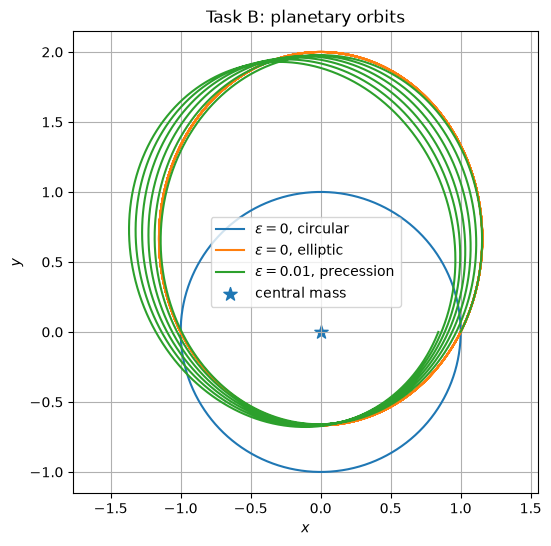

In [10]:
import numpy as np
import matplotlib.pyplot as plt

circ = np.loadtxt("ode_B_circular.data")
ell  = np.loadtxt("ode_B_elliptic.data")
prec = np.loadtxt("ode_B_precession.data")

# Dense circular reference, since the numerical solution is u(phi)=1
phi_circle = np.linspace(0, 2*np.pi, 600)
x_circle = np.cos(phi_circle)
y_circle = np.sin(phi_circle)

plt.figure(figsize=(6, 6))

plt.plot(x_circle, y_circle, label=r"$\epsilon=0$, circular")
plt.plot(ell[:, 4], ell[:, 5], label=r"$\epsilon=0$, elliptic")
plt.plot(prec[:, 4], prec[:, 5], label=r"$\epsilon=0.01$, precession")

plt.scatter([0], [0], marker="*", s=100, label="central mass")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Task B: planetary orbits")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

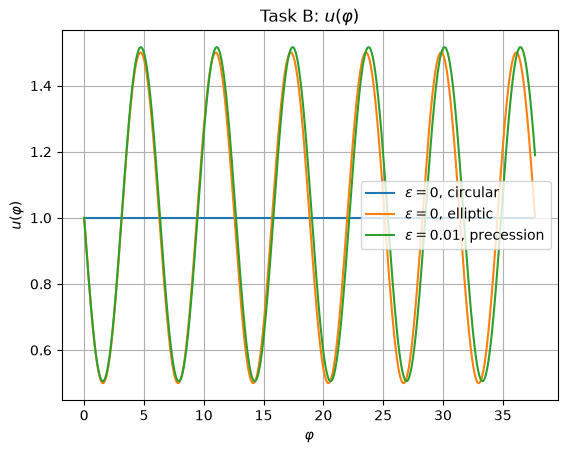

In [11]:
plt.figure()
plt.plot(circ[:, 0], circ[:, 1], label=r"$\epsilon=0$, circular")
plt.plot(ell[:, 0], ell[:, 1], label=r"$\epsilon=0$, elliptic")
plt.plot(prec[:, 0], prec[:, 1], label=r"$\epsilon=0.01$, precession")
plt.xlabel(r"$\varphi$")
plt.ylabel(r"$u(\varphi)$")
plt.title(r"Task B: $u(\varphi)$")
plt.grid(True)
plt.legend()
plt.show()

## Task B conclusion

In Task B, the adaptive ODE driver was used to solve the relativistic orbit equation

$$
u''(\varphi) + u(\varphi) = 1 + \epsilon u(\varphi)^2 .
$$

The second-order equation was rewritten as a system of two first-order equations with $y_0=u$ and $y_1=u'$. Three cases were investigated. For $\epsilon=0$ and $u'(0)=0$, the numerical solution gives a circular Newtonian orbit, as expected. For $\epsilon=0$ and $u'(0)=-0.5$, the orbit becomes an elliptic Newtonian orbit which closes on itself. Finally, for $\epsilon=0.01$ and $u'(0)=-0.5$, the orbit no longer closes after each revolution. Instead, the perihelion slowly shifts, showing the expected relativistic precession.

The plot of $u(\varphi)$ also supports this interpretation: the relativistic solution follows a similar oscillatory shape to the Newtonian elliptic case, but with a small phase shift that accumulates over several periods. Therefore, the implementation successfully demonstrates both the Newtonian limiting cases and the relativistic precession effect.


# Task C: Newtonian three-body problem

In this task, the adaptive ODE integrator is used to solve the planar Newtonian three-body problem for three equal masses with $G=1$.

The state vector is chosen as

$$
z = (x_1,y_1,x_2,y_2,x_3,y_3,v_{x1},v_{y1},v_{x2},v_{y2},v_{x3},v_{y3}) .
$$

The equations of motion are

$$
\mathbf{r}_i' = \mathbf{v}_i ,
$$

$$
\mathbf{v}_i' =
\sum_{j\neq i}
\frac{\mathbf{r}_j-\mathbf{r}_i}{|\mathbf{r}_j-\mathbf{r}_i|^3}.
$$

The initial conditions are chosen as the known stable figure-eight orbit.

In [16]:
from pathlib import Path

Path("ode_C.cpp").write_text(r'''
#include "ode.hpp"

#include <algorithm>
#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <string>
#include <vector>

pp::vec threebody_rhs(double t, const pp::vec& z) {
    (void)t;

    pp::vec dz(12, 0.0);

    // State vector:
    // z = x1,y1,x2,y2,x3,y3,vx1,vy1,vx2,vy2,vx3,vy3

    // Position derivatives = velocities
    for (int i = 0; i < 3; ++i) {
        dz[2*i]     = z[6 + 2*i];
        dz[2*i + 1] = z[6 + 2*i + 1];
    }

    // Velocity derivatives = gravitational accelerations
    for (int i = 0; i < 3; ++i) {
        double xi = z[2*i];
        double yi = z[2*i + 1];

        double ax = 0.0;
        double ay = 0.0;

        for (int j = 0; j < 3; ++j) {
            if (j == i) {
                continue;
            }

            double dx = z[2*j]     - xi;
            double dy = z[2*j + 1] - yi;

            double r2 = dx*dx + dy*dy;
            double r  = std::sqrt(r2);
            double r3 = r2*r;

            ax += dx/r3;
            ay += dy/r3;
        }

        dz[6 + 2*i]     = ax;
        dz[6 + 2*i + 1] = ay;
    }

    return dz;
}

double energy(const pp::vec& z) {
    double kinetic = 0.0;

    for (int i = 0; i < 3; ++i) {
        double vx = z[6 + 2*i];
        double vy = z[6 + 2*i + 1];

        kinetic += 0.5*(vx*vx + vy*vy);
    }

    double potential = 0.0;

    for (int i = 0; i < 3; ++i) {
        for (int j = i + 1; j < 3; ++j) {
            double dx = z[2*j]     - z[2*i];
            double dy = z[2*j + 1] - z[2*i + 1];

            double r = std::sqrt(dx*dx + dy*dy);

            potential -= 1.0/r;
        }
    }

    return kinetic + potential;
}

double center_of_mass_norm(const pp::vec& z) {
    double xcm = 0.0;
    double ycm = 0.0;

    for (int i = 0; i < 3; ++i) {
        xcm += z[2*i];
        ycm += z[2*i + 1];
    }

    xcm /= 3.0;
    ycm /= 3.0;

    return std::sqrt(xcm*xcm + ycm*ycm);
}

double momentum_norm(const pp::vec& z) {
    double px = 0.0;
    double py = 0.0;

    for (int i = 0; i < 3; ++i) {
        px += z[6 + 2*i];
        py += z[6 + 2*i + 1];
    }

    return std::sqrt(px*px + py*py);
}

void write_data(
    const std::string& filename,
    const std::vector<double>& ts,
    const std::vector<pp::vec>& zs
) {
    std::ofstream out(filename);
    out << std::setprecision(16);

    out << "# t x1 y1 x2 y2 x3 y3 vx1 vy1 vx2 vy2 vx3 vy3\n";

    for (std::size_t k = 0; k < ts.size(); ++k) {
        out << ts[k];

        for (double value : zs[k]) {
            out << " " << value;
        }

        out << "\n";
    }
}

int main() {
    std::cout << "Task C: Newtonian three-body figure-eight orbit\n";
    std::cout << "------------------------------------------------\n\n";

    // Standard figure-eight initial condition for three equal masses.
    pp::vec z0 = {
         0.97000436, -0.24308753,
        -0.97000436,  0.24308753,
         0.0,         0.0,

         0.4662036850,  0.4323657300,
         0.4662036850,  0.4323657300,
        -0.9324073700, -0.8647314600
    };

    double period = 6.32591398;

    double a = 0.0;
    double b = 3.0*period;

    double h   = 0.01;
    double acc = 1e-6;
    double eps = 1e-6;

    auto sol = pp::driver(
        threebody_rhs,
        a,
        b,
        z0,
        h,
        acc,
        eps
    );

    write_data("ode_C_threebody.data", sol.x, sol.y);

    double E0 = energy(z0);
    double E1 = energy(sol.y.back());

    double max_com = 0.0;
    double max_momentum = 0.0;

    for (const pp::vec& z : sol.y) {
        max_com = std::max(max_com, center_of_mass_norm(z));
        max_momentum = std::max(max_momentum, momentum_norm(z));
    }

    std::cout << "integration interval = [0, " << b << "]\n";
    std::cout << "number of saved points = " << sol.x.size() << "\n";
    std::cout << "accepted steps = " << sol.accepted_steps << "\n";
    std::cout << "rejected steps = " << sol.rejected_steps << "\n\n";

    std::cout << "initial energy = " << E0 << "\n";
    std::cout << "final energy   = " << E1 << "\n";
    std::cout << "energy drift   = " << std::abs(E1 - E0) << "\n\n";

    std::cout << "max center-of-mass distance from origin = " << max_com << "\n";
    std::cout << "max total momentum norm                 = " << max_momentum << "\n\n";

    std::cout << "Wrote ode_C_threebody.data\n";

    return 0;
}
''')

print("Wrote corrected ode_C.cpp")

Wrote corrected ode_C.cpp


In [17]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "ode_C.cpp",
    "-o",
    "ode_C"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./ode_C"], text=True, capture_output=True)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task C: Newtonian three-body figure-eight orbit
------------------------------------------------

integration interval = [0, 18.9777]
number of saved points = 672921
accepted steps = 672920
rejected steps = 8

initial energy = -1.28714
final energy   = -1.28714
energy drift   = 4.99267e-12

max center-of-mass distance from origin = 1.41887e-13
max total momentum norm                 = 5.52825e-14

Wrote ode_C_threebody.data




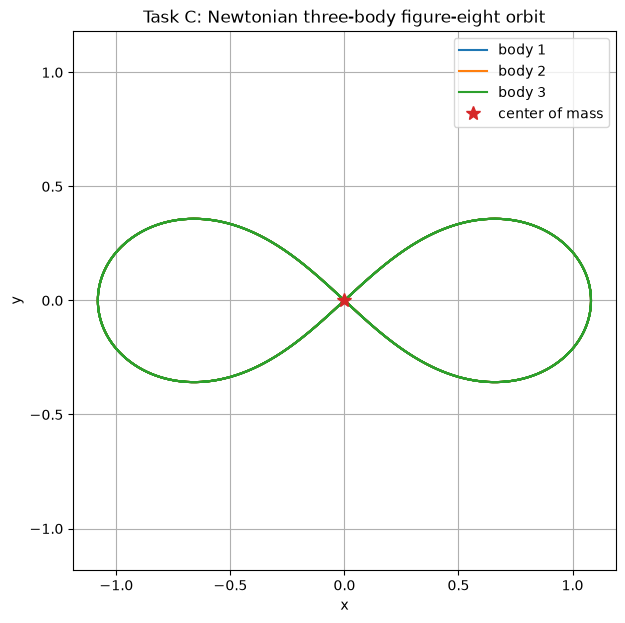

In [18]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ode_C_threebody.data")

# Downsample for plotting
skip = 200
d = data[::skip]

t = d[:, 0]

x1, y1 = d[:, 1], d[:, 2]
x2, y2 = d[:, 3], d[:, 4]
x3, y3 = d[:, 5], d[:, 6]

plt.figure(figsize=(7, 7))

plt.plot(x1, y1, label="body 1")
plt.plot(x2, y2, label="body 2")
plt.plot(x3, y3, label="body 3")

plt.plot([0], [0], "*", markersize=10, label="center of mass")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C: Newtonian three-body figure-eight orbit")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

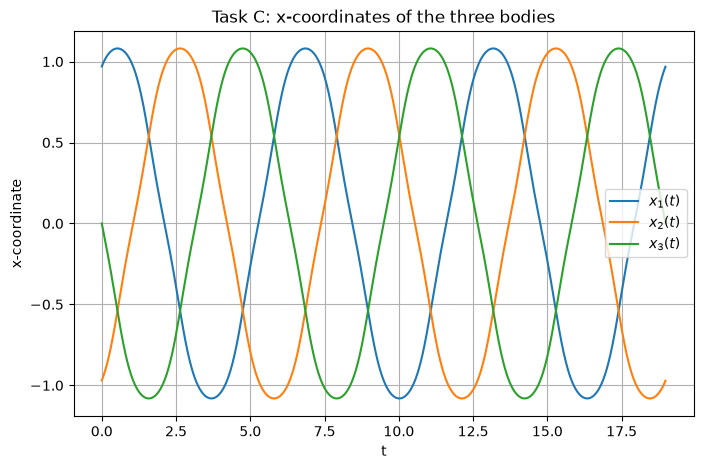

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(t, x1, label=r"$x_1(t)$")
plt.plot(t, x2, label=r"$x_2(t)$")
plt.plot(t, x3, label=r"$x_3(t)$")

plt.xlabel("t")
plt.ylabel("x-coordinate")
plt.title("Task C: x-coordinates of the three bodies")
plt.grid(True)
plt.legend()
plt.show()

## Task C conclusion

In Task C, the adaptive ODE integrator was used to solve the planar Newtonian three-body problem for three equal masses with $G=1$. The state vector contained the two-dimensional positions and velocities of all three bodies, and the gravitational acceleration of each body was computed from the other two bodies.

Using the standard initial conditions for the stable figure-eight solution, the numerical solution reproduces the expected figure-eight orbit. All three bodies follow the same curve, but with a phase shift in time. This is also visible in the plot of the $x$-coordinates, where $x_1(t)$, $x_2(t)$ and $x_3(t)$ have the same periodic structure but are shifted relative to one another.

The numerical checks show that the conserved quantities are well preserved. The energy drift is about $5\cdot 10^{-12}$, the center-of-mass drift is about $10^{-13}$, and the total momentum remains close to zero. These small errors indicate that the adaptive ODE driver integrates the three-body system accurately.

Therefore, the implemented ODE solver successfully reproduces the figure-eight three-body orbit.